## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 03 · pyBuildingEnergy as the UBEM engine: adapter, geometry and a first look

From here on the archetypes of notebook 01 are *deployed* the way Dogan et al. (2025) do
it: **every dwelling gets its own building model** — its own geometry from OS MasterMap,
its own RdSAP U-values, its heating-system family — and the archetype supplies what is not
measured (initial guesses and calibration bounds). The engine is EURAC's open-source
**pyBuildingEnergy** (EN ISO 52016-1 hourly), driven through the small `ukubem` package
in this folder:

| module | role |
|---|---|
| `ukubem.geometry` | EPC + OS record → `BUI` dictionary with the tool's conventions (plan aspect 1.5, party-wall fractions by built form, flats sharing roof/ground, RdSAP default window areas, floor U and infiltration by age band, ISO 13790 thermal-mass classes, SAP y-value bridging) |
| `ukubem.schedules` | household sampling + CREST/CHAP stochastic occupancy, EFUS heating regimes, gains and DHW (wraps `uk_ubem_schedule_generator`) → hourly arrays |
| `ukubem.engine` | quiet runs, one-off weather/solar pre-processing shared by all dwellings of a site |
| `ukubem.systems` | systems family → delivered gas / electricity / other fuel |
| `ukubem.runner` | all-core stock runs with checkpoints, LSOA aggregation, MAPE |

### Edits made to pyBuildingEnergy (`pyBuildingEnergy/src/pybuildingenergy/source/utils.py`)

Four small, backwards-compatible changes (review them with `git diff` in the repo):

1. `weather_sim_df=` keyword on the ISO 52016 core: reuse the ISO 52010 weather + solar +
   shading frame across buildings with the same site and surface layout (it was about half
   of every 16 s run);
2. `building.country_code` skips the reverse-geocoding web request the engine made on
   every run to pick the holiday calendar;
3. `building_parameters["hourly_profiles"]`: calendar-year hourly schedules (heating
   availability, occupancy, lighting, appliances, ventilation) override the weekday/weekend
   daily profiles, aligned to the engine's horizon (which carries a December warm-up month);
   an 8760-long `external_internal_gains_series` is aligned the same way;
4. the ISO 13370 ground model now takes the floor's thermal resistance from the ground
   surface's U-value instead of a hard-coded 5.3 m²K/W (a very well insulated slab).

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui, rdsap_default_window_area
from ukubem.schedules import sample_household, dwelling_schedule, deterministic_schedule
from ukubem.systems import delivered_energy, SYSTEM_DEFAULTS
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


## 1 · One dwelling, step by step

In [2]:
inputs = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
table = pd.read_parquet(TABLE_NUMERIC)
labels = pd.read_parquet(TABLE_LABELS)
A = UKGeometryAssumptions()
print(f"{len(inputs):,} dwellings with archetype-enriched inputs; EPW = {EPW.name}")

did = inputs[(inputs.accommodation_type == "Semi-detached") & (inputs.age_band_resolved == "D")].index[0]
r = inputs.loc[did]
bui, derived = build_bui(r, A)
print(f"dwelling {did}: {r.accommodation_type}, {r.built_form}, band {r.age_band_resolved}, {r.floor_area_final:.0f} m², "
      f"{r.wall_construction_resolved} ({r.wall_insulation}), {r.glazing_type} glazing, {r.heat_system}")
pd.Series({k: (round(v, 3) if isinstance(v, (int, float, np.floating)) and not isinstance(v, bool) else v) for k, v in derived.items()})

57,300 dwellings with archetype-enriched inputs; EPW = GBR_ENG_Farnborough.AP.037680_TMYx.2007-2021.epw
dwelling 9: Semi-detached, Semi-detached, band D, 62 m², Cavity (Insulated), Double glazing, Gas boiler


A_floor                             62.0
storeys_bldg                           1
storeys_dw                             1
h_storey                             2.3
footprint                           62.0
perimeter                         32.146
exposed_frac                         0.7
A_wall                            38.472
A_window                          13.282
A_party                            22.18
A_roof                              62.0
A_ground                            62.0
volume                             142.6
u_wall                               0.7
u_roof                              0.14
u_window                            3.02
u_floor                              0.7
g_window                             0.7
ach_infil                            0.4
H_ve_W_K                           35.65
psi_tb                             1.172
H_tb_W_K                          26.363
HTC_fabric_W_K                   145.486
C_total_J_K                   10230000.0
setpoint_c      

In [3]:
pd.DataFrame(bui["building_surface"])[["name", "type", "area", "u_value", "thermal_capacity", "orientation"]].round(2)

,name,type,area,u_value,thermal_capacity,orientation
0,Wall N,opaque,9.62,0.70,532849.05,"{'azimuth': 0, 'tilt': 90}"
1,Wall E,opaque,9.62,0.70,532849.05,"{'azimuth': 90, 'tilt': 90}"
2,Wall S,opaque,9.62,0.70,532849.05,"{'azimuth': 180, 'tilt': 90}"
3,Wall W,opaque,9.62,0.70,532849.05,"{'azimuth': 270, 'tilt': 90}"
4,Win N,transparent,3.32,3.02,0.00,"{'azimuth': 0, 'tilt': 90}"
5,Win E,transparent,3.32,3.02,0.00,"{'azimuth': 90, 'tilt': 90}"
6,Win S,transparent,3.32,3.02,0.00,"{'azimuth': 180, 'tilt': 90}"
7,Win W,transparent,3.32,3.02,0.00,"{'azimuth': 270, 'tilt': 90}"
8,Roof,opaque,62.00,0.14,3434888.99,"{'azimuth': 0, 'tilt': 0}"
9,Ground,opaque,62.00,0.70,3434888.99,"{'azimuth': 0, 'tilt': 0}"


In [4]:
t0 = time.time()
hourly, annual, secs = run_building(bui, EPW, PBE_SRC, use_weather_cache=False)
hourly2, annual2, secs2 = run_building(bui, EPW, PBE_SRC, use_weather_cache=True)
res = annual_summary(hourly, annual, derived["A_floor"])
print(f"first run (computes the weather frame) {secs:.1f} s, second run (cached) {secs2:.1f} s; identical: {np.isclose(hourly['Q_HC'].sum(), hourly2['Q_HC'].sum())}")
print(f"space-heating need {res['Q_H_kWh']:,.0f} kWh/yr = {res['Q_H_kWh_m2']:.0f} kWh/m²")
pd.Series(res).round(1)

first run (computes the weather frame) 16.0 s, second run (cached) 12.1 s; identical: True
space-heating need 4,543 kWh/yr = 73 kWh/m²


Q_H_kWh                  4543.2
Q_C_kWh                    -0.0
T_op_mean_C                20.1
T_op_heating_season_C      18.5
heating_hours            2255.0
peak_heat_W              7258.0
Q_H_kWh_m2                 73.3
Q_solar_gains_kWh        4927.7
Q_internal_gains_kWh     1520.7
Q_tr_total_loss_kWh      2975.0
Q_ve_loss_kWh            3044.9
Q_ground_loss_kWh        5987.5
Q_tb_loss_kWh              96.1
Q_tr_window_loss_kWh     2903.0
Q_tr_opaque_loss_kWh     1928.7
dtype: float64

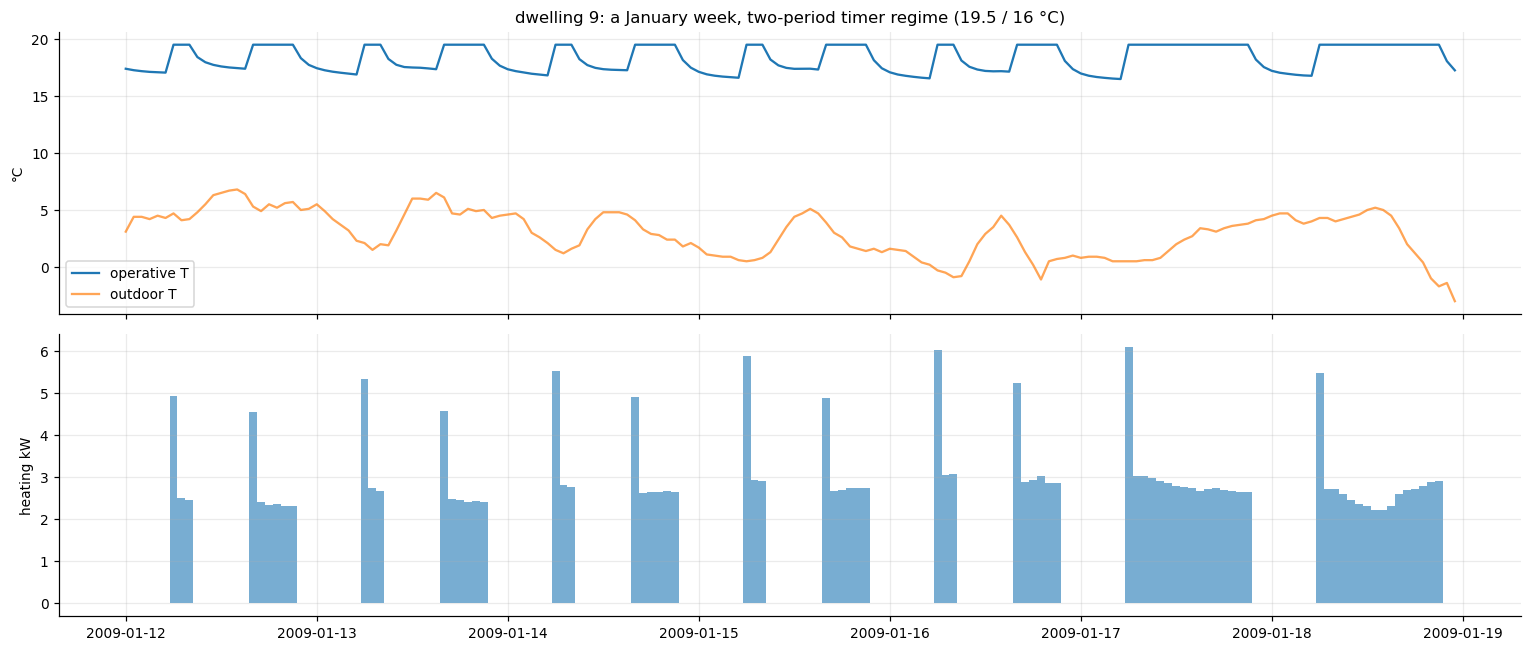

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
wk = hourly.loc["2009-01-12":"2009-01-18"]
axes[0].plot(wk.index, wk["T_op"], label="operative T"); axes[0].plot(wk.index, wk["T_ext"], label="outdoor T", alpha=0.7)
axes[0].set_ylabel("°C"); axes[0].legend(); axes[0].set_title(f"dwelling {did}: a January week, two-period timer regime (19.5 / 16 °C)")
axes[1].fill_between(wk.index, 0, wk["Q_HC"] / 1000, step="mid", alpha=0.6); axes[1].set_ylabel("heating kW")
plt.tight_layout(); fig.savefig(FIG_UBEM / "03_one_dwelling_week.png", bbox_inches="tight"); plt.show()

## 2 · Same dwelling with a stochastic household (CREST/CHAP regime)

household family_children (4 people), EFUS pattern P5_TWO_SHORT, thermostat 21.0 °C, season start month 9 for 5 months, heating available 8 % of hours
space-heating need 1,583 kWh/yr = 26 kWh/m² (deterministic regime: 73);  DHW 2,352 kWh, appliances+lighting 1,174 kWh


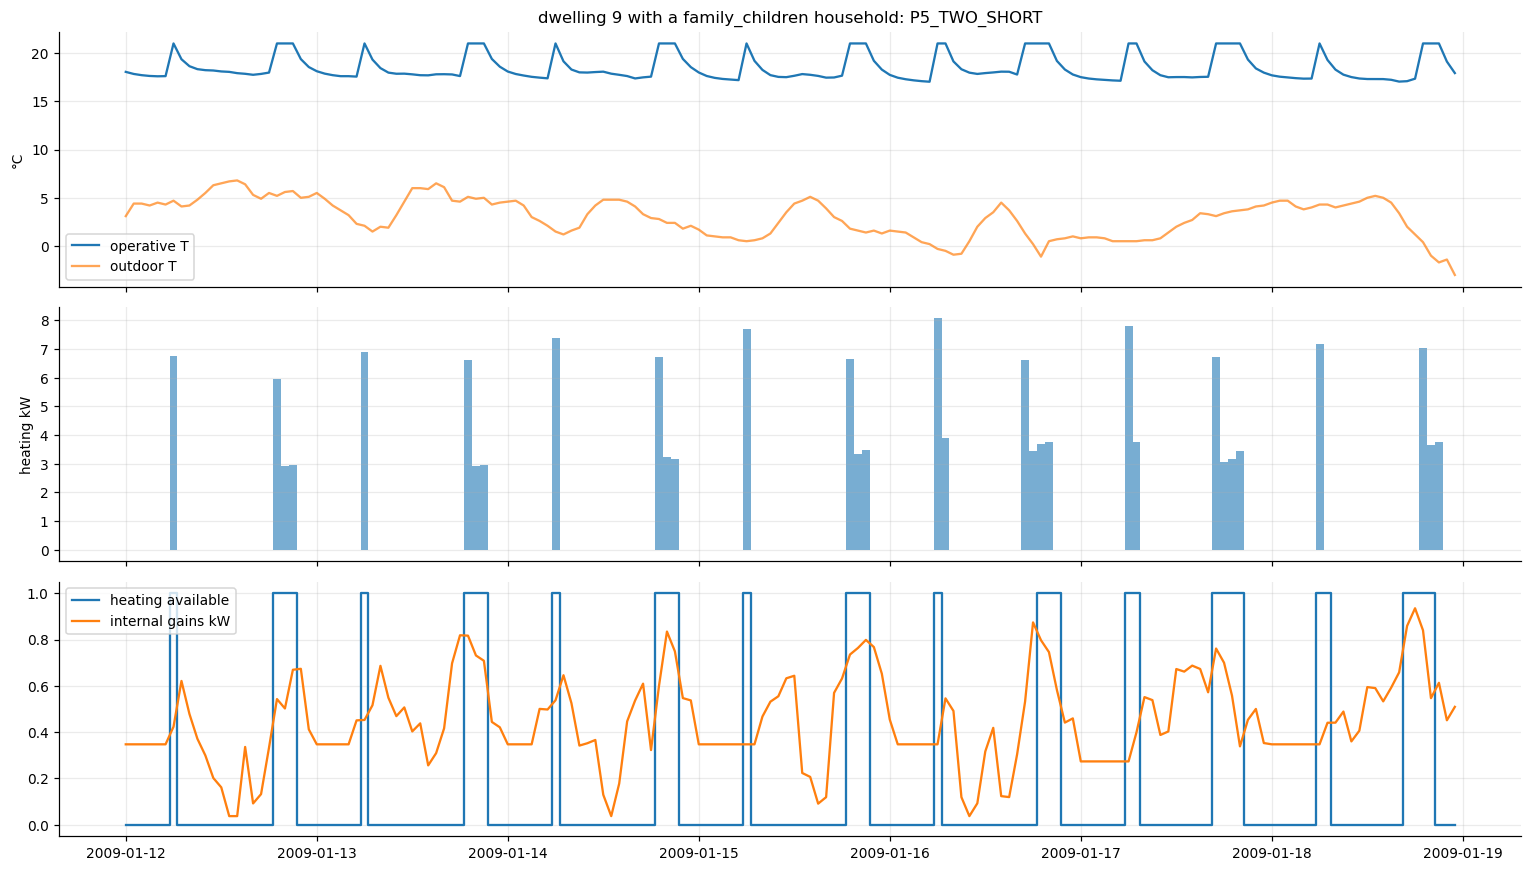

In [6]:
rng = np.random.default_rng(int(did))
hh = sample_household(r.accommodation_type, r.floor_area_final, r.tenure, rng)
sch = dwelling_schedule(str(did), hh, r.floor_area_final, year=2021, seed=int(did), timestep_minutes=60)
bui_s, der_s = build_bui(r, A, schedule=sch)
hourly_s, annual_s, secs_s = run_building(bui_s, EPW, PBE_SRC, external_internal_gains_w=sch["gains_w"])
res_s = annual_summary(hourly_s, annual_s, der_s["A_floor"])
print(f"household {hh} ({sch['people']} people), EFUS pattern {sch['heating_pattern']}, thermostat {sch['setpoint_c']:.1f} °C, "
      f"season start month {sch['season_start_month']} for {sch['season_length_months']} months, heating available {100*sch['heating_share_of_hours']:.0f} % of hours")
print(f"space-heating need {res_s['Q_H_kWh']:,.0f} kWh/yr = {res_s['Q_H_kWh_m2']:.0f} kWh/m² (deterministic regime: {res['Q_H_kWh_m2']:.0f});  "
      f"DHW {sch['dhw_kWh_year']:,.0f} kWh, appliances+lighting {sch['elec_kWh']:,.0f} kWh")
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
wk = hourly_s.loc["2009-01-12":"2009-01-18"]; idx = pd.date_range("2021-01-11", periods=24*7, freq="h")
pos = (idx.dayofyear - 1) * 24 + idx.hour
axes[0].plot(wk.index, wk["T_op"], label="operative T"); axes[0].plot(wk.index, wk["T_ext"], label="outdoor T", alpha=0.7); axes[0].legend(); axes[0].set_ylabel("°C")
axes[1].fill_between(wk.index, 0, wk["Q_HC"] / 1000, step="mid", alpha=0.6); axes[1].set_ylabel("heating kW")
axes[2].step(wk.index, sch["heating_on"][pos], where="mid", label="heating available"); axes[2].plot(wk.index, sch["gains_w"][pos] / 1000, label="internal gains kW"); axes[2].legend(); axes[2].set_ylabel("")
axes[0].set_title(f"dwelling {did} with a {hh} household: {sch['heating_pattern']}")
plt.tight_layout(); fig.savefig(FIG_UBEM / "03_one_dwelling_week_stochastic.png", bbox_inches="tight"); plt.show()

## 3 · One dwelling per construction sub-archetype (the 38 medoids), both regimes, all cores

This is the shape of every later run: a table of dwellings in, one summary row per dwelling
out, `joblib` across the 32 cores, each worker keeping its own weather cache.

In [7]:
from joblib import Parallel, delayed
reps = json.load(open(EXPORT_DIR / "cluster_representatives.json"))
medoids = [int(v["medoid"]["dwelling_id"]) for v in reps.values()]
rows = inputs.loc[medoids]
t0 = time.time()
chunks = [rows.iloc[i:i + 2] for i in range(0, len(rows), 2)]
det = sum(Parallel(n_jobs=N_JOBS)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A, False, SEED, 2021, None) for c in chunks), [])
sto = sum(Parallel(n_jobs=N_JOBS)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A, True, SEED, 2021, None) for c in chunks), [])
det, sto = pd.DataFrame(det).set_index("dwelling_id"), pd.DataFrame(sto).set_index("dwelling_id")
print(f"{2*len(rows)} simulations in {(time.time()-t0)/60:.1f} min on {N_JOBS} cores  ({det['seconds'].mean():.1f} s each inside the worker)")
cmp = pd.DataFrame({"archetype": inputs.loc[medoids, "construction_sa"].values,
                    "type": inputs.loc[medoids, "accommodation_type"].values, "age": inputs.loc[medoids, "age_band_resolved"].values,
                    "A_m2": det["A_floor"].values, "HTC_W_m2K": det["HTC_per_m2"].values,
                    "ISO52016_timer_regime": det["Q_H_kWh_m2"].values, "ISO52016_CHAP_household": sto["Q_H_kWh_m2"].values,
                    "household": sto["household_archetype"].values, "pattern": sto["heating_pattern"].values,
                    "T_op_winter_CHAP": sto["T_op_heating_season_C"].values}, index=medoids)
cmp.to_csv(UBEM_OUT / "03_medoids_two_regimes.csv")
cmp.round(1)

68 simulations in 1.6 min on 32 cores  (16.9 s each inside the worker)


,archetype,type,age,A_m2,HTC_W_m2K,ISO52016_timer_regime,ISO52016_CHAP_household,household,pattern,T_op_winter_CHAP
1543,C.Det.1,Detached,D,151.0,3.6,108.9,61.8,working_couple,P9_ACTIVE_OCCUPANCY,17.6
698,C.Det.2,Detached,D,127.0,3.7,134.8,105.5,family_children,P9_ACTIVE_OCCUPANCY,17.9
2511,C.Det.3,Detached,H,119.0,2.1,55.1,24.8,family_children,P6_MORNING_SHORT_EVENING_SUSTAINED,18.7
27512,C.Det.4,Detached,L,186.0,1.5,16.8,0.0,retired_couple,P5_TWO_SHORT,19.7
1621,C.Det.5,Detached,B,189.0,3.9,137.0,110.7,working_couple,P9_ACTIVE_OCCUPANCY,17.4
13237,C.Det.6,Detached,E,129.0,5.0,189.1,97.4,family_children,P9_ACTIVE_OCCUPANCY,16.1
1248,C.Det.7,Detached,C,309.0,4.2,160.3,64.1,working_couple,P9_ACTIVE_OCCUPANCY,14.7
5890,C.Det.8,Detached,C,87.0,4.7,173.1,74.3,working_couple,P8_THREE_PERIODS,14.6
2145,C.Det.9,Detached,B,101.0,4.9,203.8,135.4,single_retired,P1_ALL_DAY_FROM_WAKE,17.2
440,C.Flat.1,Flat,F,45.0,2.2,49.4,30.5,single_working,P5_TWO_SHORT,19.9


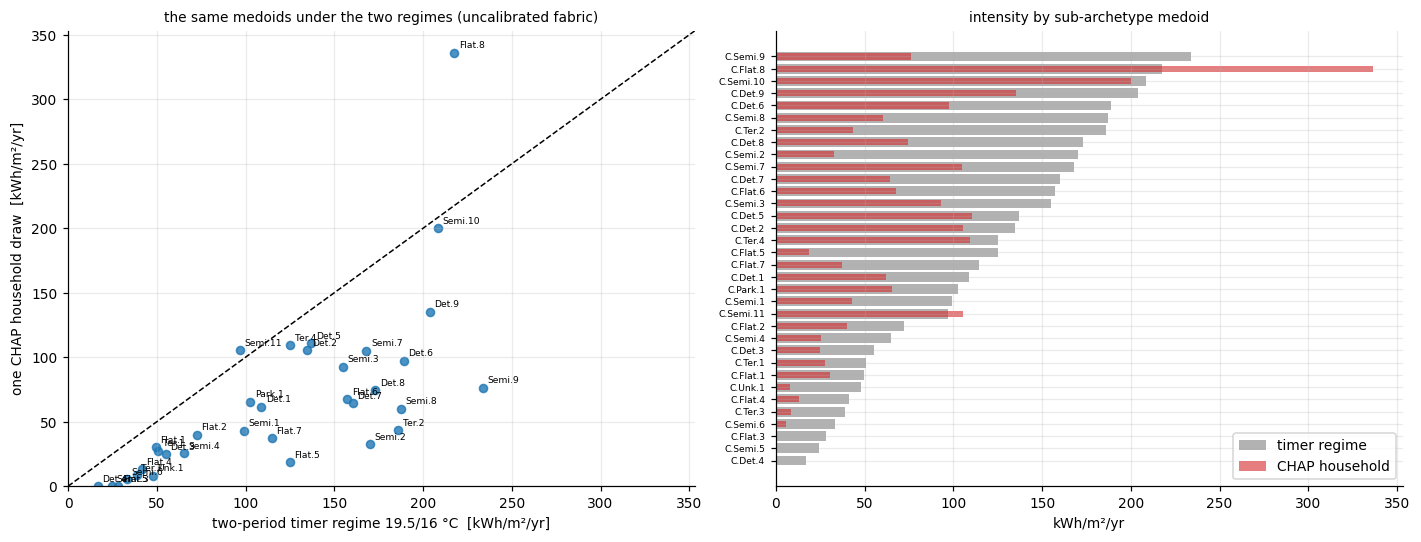

correlation between the regimes across medoids: 0.69; median ratio household/timer = 0.43
Uncalibrated fabric with either regime is the starting point; the calibration in notebook 06 fits the fabric scalers, infiltration, gains and setpoints to the LSOA meters.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = cmp[["ISO52016_timer_regime", "ISO52016_CHAP_household"]].max().max() * 1.05
axes[0].scatter(cmp["ISO52016_timer_regime"], cmp["ISO52016_CHAP_household"], s=28, alpha=0.8)
for i, row in cmp.iterrows():
    axes[0].annotate(row["archetype"].replace("C.", ""), (row["ISO52016_timer_regime"], row["ISO52016_CHAP_household"]), fontsize=6, xytext=(3, 3), textcoords="offset points")
axes[0].plot([0, lim], [0, lim], "k--", lw=1); axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("two-period timer regime 19.5/16 °C  [kWh/m²/yr]"); axes[0].set_ylabel("one CHAP household draw  [kWh/m²/yr]"); axes[0].set_title("the same medoids under the two regimes (uncalibrated fabric)", fontsize=9)
order_ = cmp.sort_values("ISO52016_timer_regime").index
axes[1].barh(range(len(order_)), cmp.loc[order_, "ISO52016_timer_regime"], color="grey", alpha=0.6, label="timer regime")
axes[1].barh(range(len(order_)), cmp.loc[order_, "ISO52016_CHAP_household"], color="tab:red", alpha=0.6, height=0.5, label="CHAP household")
axes[1].set_yticks(range(len(order_))); axes[1].set_yticklabels(cmp.loc[order_, "archetype"], fontsize=6); axes[1].set_xlabel("kWh/m²/yr"); axes[1].legend(); axes[1].set_title("intensity by sub-archetype medoid", fontsize=9)
plt.tight_layout(); fig.savefig(FIG_UBEM / "03_medoids_two_regimes.png", bbox_inches="tight"); plt.show()
r1 = np.corrcoef(cmp["ISO52016_timer_regime"], cmp["ISO52016_CHAP_household"])[0, 1]
print(f"correlation between the regimes across medoids: {r1:.2f}; median ratio household/timer = {(cmp['ISO52016_CHAP_household']/cmp['ISO52016_timer_regime']).median():.2f}")
print("Uncalibrated fabric with either regime is the starting point; the calibration in notebook 06 fits the fabric scalers, infiltration, gains and setpoints to the LSOA meters.")

**Next:** `04_household_schedules.ipynb` — the stochastic household layer in detail.